ANOVA 티테스트

In [1]:
# 아노바
# 3개 이상 그룹으 평균이 서로 같은지 확인하는 검정 또는
# 여러 그룹 평균이 전체적으로 같은지 한 번에 검정하는 방법
# ANOVA는 독립성은 필수지만, 정규성과 등분산성은 “완벽해야 하는 조건”이 아니라 “충족되면 좋은 조건”
# 1. 그룹 간 차이(그룹평균들 사이 차이)
# 2. 그룹 내부 차이(같은 그룹 안에서 퍼짐)

In [2]:
# 독립성 : 각 데이터가 서로 영향을 주지 않는 상태
# 1반, 2반, 3반의 반 평균
# 유저1, 유저2, 유저3 의 사용시간

In [3]:
# 통계흐름

# 데이터 확인
# - 여러집단 각각 데이터 확인 (group1, group2,group3, ... )
# 기본통계 확인 (mean, std, min, max)

# 시각화와 같은 방법으로 분포 확인
# - histogram (group별)
# - boxplot (group 비교)
# 분포 모양 확인, 이상치 확인
# - 이상치 있으면 확인 후 처리 (무조건 제거 X)
#   → 측정 오류면 제거, 실제 값이면 유지

# 분포 상태 체크
# 심하게 치우쳤는지 확인
# 정규성은 ANOVA가 어느 정도 robust하지만 참고는 해야 함
# ANOVA는 정규성에 완전히 민감하지 않음
# 필요 시:
# log transform
# sqrt transform
# 비모수 검정 고려 (Kruskal-Wallis)

# 등분산성 확인
# - Levene test로 여러 그룹 분산 비교
# 등분산성이 깨지면 ANOVA 버전의 Welch t-test 사용
# 정규성이 심하게 깨지면 Kruskal-Wallis (비모수) 사

# Anova 수행

# 사후 검정(post-hoc)
# 만약 평균이 다르다면 아노바는 그 중 누가 다른지 알 수 없음
# ANOVA 유의할 때만 Tukey HSD을 진행함

# 신뢰구간 확인
# 그룹 간 차이의 범위 확인
# post-hoc 결과와 같이 해석

# effect size확인
# omega squared (ω²) : 전체 변동 중에서 ‘실제 효과(모집단 수준)’로 설명되는 비율

In [4]:
# 데이터 생성
import numpy as np
import pandas as pd

np.random.seed(42)  # 재현성

# 그룹 A
group_a = np.random.normal(loc=48, scale=5, size=30)

# 그룹 B
group_b = np.random.normal(loc=55, scale=5, size=30)

# 그룹 C
group_c = np.random.normal(loc=62, scale=5, size=30)

df_a = pd.DataFrame({
    "session_time": group_a,
    "group": "A"
})

df_b = pd.DataFrame({
    "session_time": group_b,
    "group": "B"
})

df_c = pd.DataFrame({
    "session_time": group_c,
    "group": "C"
})

In [5]:
# 세그룹의 분포 확인
# 아노바에서는 각 그룹의 내부 퍼짐 std
# 그룹간의 평균거리 mean을 위주로 확인

# A 평균은 B보다 얼마나 떨어져 있는가?
# 그 차이가 A 내부 퍼짐보다 큰가?

print('A그룹')
print(df_a.describe())

print()

print('B그룹')
print(df_b.describe())

print()

print('C그룹')
print(df_c.describe())

A그룹
       session_time
count     30.000000
mean      47.059266
std        4.500032
min       38.433599
25%       45.044746
50%       46.829274
75%       49.801677
max       55.896064

B그룹
       session_time
count     30.000000
mean      54.394188
std        4.655511
min       45.201649
25%       51.454432
50%       54.677136
75%       57.723309
max       64.261391

C그룹
       session_time
count     30.000000
mean      62.064424
std        4.959915
min       48.901274
25%       59.429290
50%       62.128053
75%       65.688556
max       69.823218


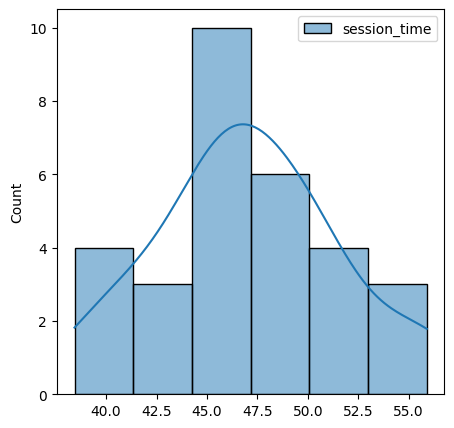

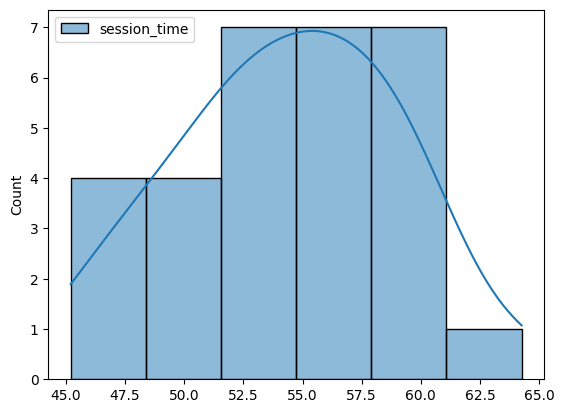

<Axes: ylabel='Count'>

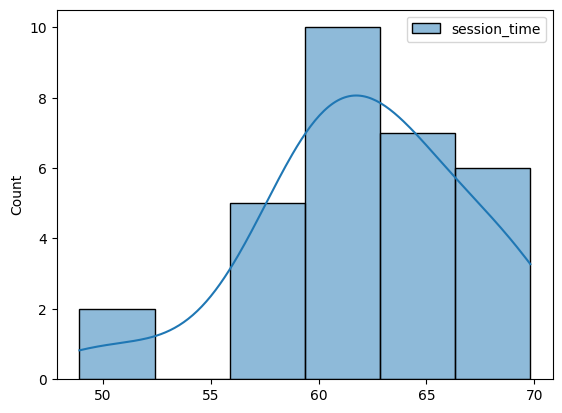

In [6]:
# 각 그룹 시각화_히스토그램
# 정규성 만족하는지 대략 확인

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(5,5))

sns.histplot(df_a, kde = True)
plt.show()
sns.histplot(df_b, kde = True)
plt.show()
sns.histplot(df_c,kde = True)

<Axes: xlabel='group', ylabel='session_time'>

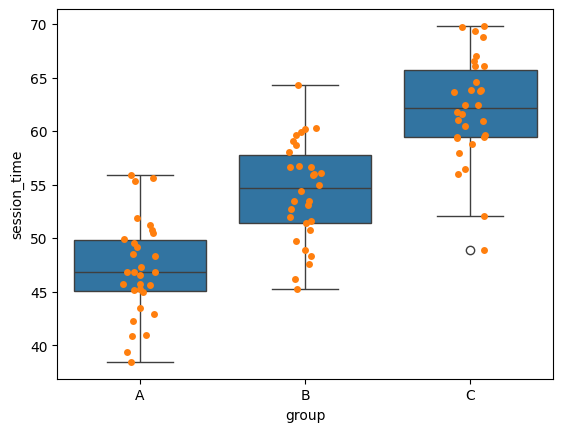

In [7]:
# 박스플롯_시각화

# [확인해야 할것]
# 박스 높이 차이 (IQR)
# 수염 길이
# 퍼짐 정도
# 박스의 겹침 (IQR이 비슷)
# 박스의 겹침이 많으면 그룹간의 차이가 적음, 겹침이 적으면 차이 있음
# 박스가 겹친다는 건 “그룹 간 차이보다 그룹 내부 변동이 더 크다”는 뜻

# 따라서 아노바에서는 한 캔버스에 박스 플롯을 같이 그려서 확인함

import pandas as pd

total_df = pd.concat([df_a, df_b, df_c])
sns.boxplot(x = total_df['group'], y = total_df['session_time'])
sns.stripplot(x= total_df['group'], y = total_df['session_time'])


# 3개의 그룹의 IQR이 겹치지 않고
# 그룹c에 이상치 발견되었으나 전체적인 분포가 비슷하여 삭제X

In [8]:
# 등분산성 수치 확인

from scipy import stats

a = total_df[total_df['group']=='A']['session_time']
b = total_df[total_df['group']=='B']['session_time']
c = total_df[total_df['group']=='C']['session_time']

# stat : 검정통계량(데이터가 가설에서 얼마나 벗어났는지 숫자로 표현한 값)
# 원샘플 티테스트도 그렇고 독립표본도 그렇고 검정통계량은 직접하지않고 p값을 주로 봄
# 검정통계량은 해석기준이 없고 데이터마다 스케일이 달라서 절대기준이 없음
# 또한 이미 p값이 stat을 기반으로 계산된 최종결과이기때문
stat, p_value = stats.levene(a,b,c)
print(f'검정통계량 : {stat}')
print(f'p-value : {p_value}') # 0.05보다 큼

# 귀무가설이 두 그룹의 등분산성이 같다고 가정했기때문에
# 0.05보다 높은 0.8이 나와서 귀무가설을 기각하지못함(등분산성이 같음)

검정통계량 : 0.14798127787925683
p-value : 0.8626638812717601


In [9]:
# ANOVA 진행

from scipy import stats

a = total_df[total_df['group']=='A']['session_time']
b = total_df[total_df['group']=='B']['session_time']
c = total_df[total_df['group']=="C"]['session_time']

f, p_value = stats.f_oneway(a,b,c)

# 아노바 f값 : 그룹 간 차이 / 그룹 내부 변동
# f값이 크다 : 그룹 간 차이 > 그룹 내부 변동 즉 그룹들이 확실히 다르다
# f값이 작다 : 그룹간 차이 = 그룹 내부 변동 즉 차이가 별로 없다
print(f'{f}') # 1에 가까울 수록 차이가 없음. 지금값은 76이 나왔기때문에 차이가 큼
print(f'{p_value}') # 0.05보다작은 값으로 차이 없다라는 귀무가설 기각 가능

76.16442907090064
7.634876173752023e-20


In [10]:
# 신뢰구간 확인(lower, upper)

# Tukey HSD : 아노바에서 유의미한 차이가 있을때 어떤 그룹끼리 차이 나는지 알려주는 사후검정 방법
# Tukey HSD : 모든 그룹 쌍을 비교하면서 “다중비교 오류를 통제한 평균 차이 검정”
# 단순 아노바는 여러 그룹의 평균차이가 있냐없냐만 확인하기때문에 누가 다른지 모름
# 따라서 p값이 0.05보다 작을 경우 어떤 평균이 다른지 tukey로 확인해야함

from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(
    endog = total_df['session_time'], # y값(우리가 측정한 값)
    groups = total_df['group'], # x값(독립변수, 비교 그룹 정보)
    alpha = 0.05 # 유의수준. 0.05기준으로 판단하기때문에 5를 넣은것
)

print(result)
# 해석방법
# A      B   7.3349   0.0 4.4357 10.2341   True
# A가 B보다 약 7,3더 크고 True이기때문에 통계적으로 유의
# meandiff의 결과를 보고 어느 그룹이 가장 큰지 순서대로 해석해야함
# A - B = 7.33  → A > B
# A - C = 15.00 → A > C
# B - C = 7.67 → B > C
# A < B < C

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower   upper  reject
--------------------------------------------------
     A      B   7.3349   0.0 4.4357 10.2341   True
     A      C  15.0052   0.0 12.106 17.9044   True
     B      C   7.6702   0.0  4.771 10.5694   True
--------------------------------------------------


In [11]:
# effect size확인
# 아노바의 effect size는 ω² (omega squared)를 사용. 차이가 얼마나 크냐?를 확인하는것
# ω² (omega squared) 공식 : ω² = (SS_between - (k-1)*MS_within) / (SS_total + MS_within)
# ω² = “전체 변동 중에서 그룹이 설명하는 비율”

# [해석 기준]
# 0.01 → 작은 효과
# 0.06 → 중간 효과
# 0.14 → 큰 효과

import numpy as np

# 각각 그룹의 데이터 합치기
groups = [a, b, c]
all_data = np.concatenate(groups)

# 전체 데이터 평균 구하기
grand_mean = np.mean(all_data)

# SS total_ 전체 변동 구하기 데이터가 얼마나 펴저있는지 확인하기 위해
ss_total = np.sum((all_data - grand_mean) ** 2)

# SS between_ 그룹간 차이 확인. 그룹 평균차이로 생긴 변동확인
ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)

# SS within_ 그룹 내부 변동확인
ss_within = ss_total - ss_between

k = len(groups) # 그룹 개수
n = len(all_data) # 전체 샘플 수

# 평균 제곱 오차(노이즈 평균 크기 / 분산의 추정값)
ms_within = ss_within / (n - k)

omega_sq = (ss_between - (k - 1) * ms_within) / (ss_total + ms_within)

print("omega squared:", omega_sq) # 0.6으로 중간효과
# 그룹 차이가 전체 데이터 구조의 60%를 설명
# 나머지 40%는 개인차 또는 노이즈

omega squared: 0.6255131377235714


반복측정 ANOVA(Repeated Measures ANOVA)_독립성이 깨졌을때의 아노바 분석방법

In [12]:
# 독립성이 깨진경우
# A유저1일차 기록, A유저2일차 기록 A유저3일차 기록
# 이 같이 같은 사람이 계속해서 등장하거나 데이터가 연결되는 경우
# 시간성을 가진 데이터(주가, 트래픽, 센서 데이터 등 오늘값이 어제와 연결)

# 독립성이 깨졌더라도 아노바는 할 수 있음
# 독립성이 깨진 데이터에서는 일반 ANOVA는 사용할 수 없지만,
# 대신 반복측정 ANOVA나 혼합모형처럼 의존 구조를 반영한 ANOVA를 사용

# 독립성이 깨졌는데도 아노바를 하는 이유
# 아노바자체는 평균 비교를 위한 선형모형의 특수 형태임
# one_way 아노바의 경우에는 각 관측값이 서로 독립된다고 봄
# 이 경우 독립성이 깨지면 정보가 중복되고 p값이 왜곡되는등의 문제가 발생
# 하지만 아노바 자체는 여러그룹의 평균차이이기때문에 아노바라는 구조를 확장해서 사용하는것임

In [13]:
# Repeated ANOVA
# 같은 대상을 여러번 측정했을때 그 변화에 대한 평균차이를 분석하는 아노바
# 카이제곱의 경우에는 범주형데이터를 사용하고 repeated 아노바는 연속형데이터를 다룸

In [14]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 30  # 사용자 수

# 개인 baseline (사람마다 기본 체류시간 다름)
baseline = np.random.normal(loc=50, scale=8, size=n)

# 각 조건 효과 (같은 사람이지만 UI에 따라 변화)
A = baseline + np.random.normal(0, 2, n)          # 기준
B = baseline + 3 + np.random.normal(0, 2, n)      # 조금 개선
C = baseline + 5 + np.random.normal(0, 2, n)      # 더 개선

df = pd.DataFrame({
    "user": np.arange(n),
    "A": A,
    "B": B,
    "C": C
})

In [20]:
# 기초 통계확인


print('A그룹')
print(df['A'].describe())

print()

print('B그룹')
print(df['B'].describe())

print()
print('C그룹')
print(df['C'].describe())

A그룹
count    30.000000
mean     48.252500
std       7.613072
min      33.243613
25%      43.706377
50%      48.477987
75%      52.712066
max      63.051430
Name: A, dtype: float64

B그룹
count    30.000000
mean     51.520594
std       7.447788
min      33.961167
25%      47.054806
50%      52.129125
75%      56.003733
max      65.489682
Name: B, dtype: float64

C그룹
count    30.000000
mean     53.454322
std       6.863076
min      38.089204
25%      50.214960
50%      52.810649
75%      57.519970
max      68.225943
Name: C, dtype: float64


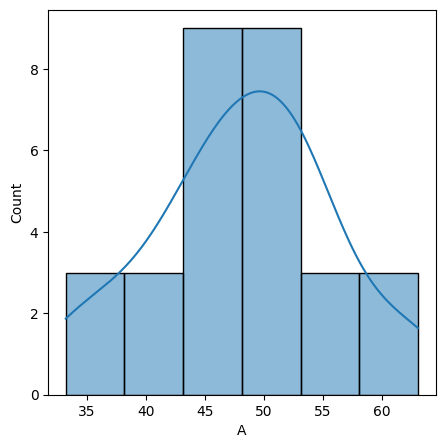

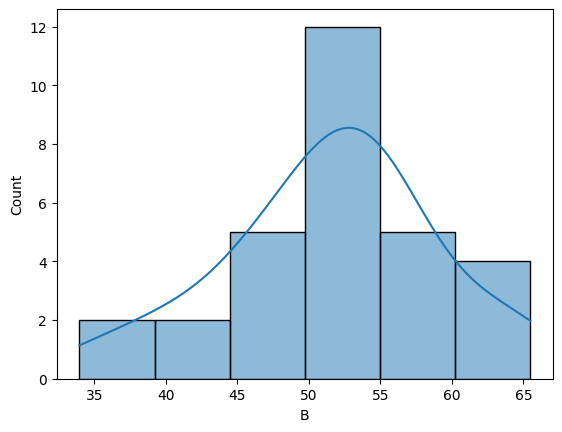

<Axes: xlabel='C', ylabel='Count'>

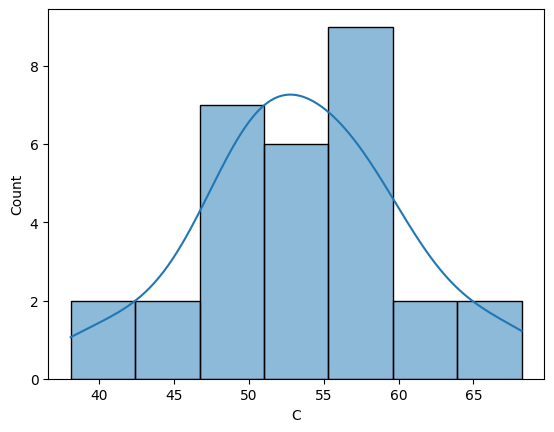

In [21]:
# 히스토그램 시각화

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(5,5))

sns.histplot(df['A'], kde = True)
plt.show()
sns.histplot(df['B'], kde = True)
plt.show()
sns.histplot(df['C'],kde = True)

In [ ]:
# 박스플롯

sns.boxplot()